# Importing Libraries


In [25]:
import cv2
import mediapipe as mp

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import random
import os
from tqdm.notebook import tqdm

import IPython.display as ipd

# Extracting Required Paths


In [26]:
train_data  = pd.read_csv(r'Dataset\train.csv')
train_data.head()    

,parent_label,label,video_path,include_50
0,Colours,50. Yellow,Colours/50. Yellow/MVI_5194.mp4,False
1,Clothes,43. Pant,Clothes/43. Pant/MVI_3709.mp4,False
2,Jobs,99. Job,Jobs/99. Job/MVI_4796.mp4,False
3,Jobs,91. Priest,Jobs/91. Priest/MVI_5345.mp4,False
4,Adjectives,96. wet,Adjectives/96. wet/MVI_5246.mp4,False


In [27]:
output_label = train_data['label']
for i in range(len(output_label)):
    output_label[i] = output_label[i].split(' ')[1:]
    output_label[i] = " ".join(output_label[i])
output_label

C:\Users\swast\AppData\Local\Temp\ipykernel_13024\814516863.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  output_label[i] = output_label[i].split(' ')[1:]
C:\Users\swast\AppData\Local\Temp\ipykernel_13024\814516863.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  output_label[i] = " ".join(output_label[i])
C:\Users\swast\AppData\Local\Temp\ipykernel_13024\814516863.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  output_lab

0             Yellow
1               Pant
2                Job
3             Priest
4                wet
            ...     
3811           Hello
3812    train ticket
3813    small little
3814            Fall
3815            Bank
Name: label, Length: 3816, dtype: object

In [28]:
input_path = []

for i in range(0, len(train_data)):
    input_path.append('Dataset/' +train_data['video_path'][i])


## Vedio Augmentaion

1. Centre Crop
2. Flip
3. Org  
4. Upsample
5. Downsample

### Optional (Optional Experimentrs)
6. sharpen 
7. blurred

# Loading Video in OpenCV

In [29]:
random_video = random.choice(input_path)
print(random_video.split("/")[-2])

cap = cv2.VideoCapture(random_video)
print(f"Video Resolution: {cap.get(cv2.CAP_PROP_FRAME_WIDTH)} x {cap.get(cv2.CAP_PROP_FRAME_HEIGHT)}")
print(f"FPS: {cap.get(cv2.CAP_PROP_FPS)}")

ipd.Video(random_video,width=700)

77. Month
Video Resolution: 1920.0 x 1080.0
FPS: 25.0


# Prepering Mediapipe

In [30]:
mp_holistic = mp.solutions.holistic # Holistic model
mp_drawing = mp.solutions.drawing_utils # Drawing utilities

In [31]:
def mediapipe_detection(image, model) -> tuple:
    image_ = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 
    image_.flags.writeable = False                  
    results = model.process(image_) 
    image_.flags.writeable = True                   
    image = cv2.cvtColor(image_, cv2.COLOR_RGB2BGR) 
    return image, results

In [32]:
def draw_landmarks(image, results) -> None:
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS) # Draw pose connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw right hand connections

In [33]:
def draw_styled_landmarks(image, results) -> None:
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    
    # Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 

In [34]:
def extract_keypoints(results) -> np.array:
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, face, lh, rh])

# Collecting MP data


## INCLUDE 50


In [35]:

input_path_I50 = []
for i in range(len(train_data)):
    if train_data['include_50'][i] == True:
        input_path_I50.append("Dataset\\" + train_data['video_path'][i])
        

input_path_I50= pd.Series(input_path_I50)

input_path_I50.sample(10)


623              Dataset\Clothes/37. Hat/MVI_4197.mp4
206         Dataset\Adjectives/79. short/MVI_5112.mp4
608    Dataset\Pronouns/46. you (plural)/MVI_0023.mp4
358     Dataset\Places/28. Store or Shop/MVI_3555.mp4
662              Dataset\Colours/47. Red/MVI_5039.mp4
98               Dataset\Home/28. Window/MVI_4365.mp4
308         Dataset\Adjectives/79. short/MVI_5110.mp4
60               Dataset\Animals/4. Bird/MVI_3013.mp4
564          Dataset\Greetings/48. Hello/MVI_9954.mp4
233           Dataset\Adjectives/87. hot/MVI_5217.mp4
dtype: object

In [36]:

output_label_I50 = []
for i in range(len(train_data)):
    if train_data['include_50'][i] == True:
        output_label_I50.append(train_data['label'][i])
        

output_label_I50= pd.Series(output_label_I50)

output_label_I50.sample(10)


192        Car
491      White
267       Year
603         it
300       Bird
609       Bird
486    T-Shirt
412        dry
215    T-Shirt
184       Time
dtype: object

In [37]:
output_label_dict_I50 = {}

for i in range(len(output_label_I50)):
    output_label_dict_I50[output_label_I50[i]] = output_label_dict_I50.get(output_label_I50[i],0)+1 

output_label_dict_I50

{'loud': 13,
 'House': 18,
 'big large': 15,
 'Priest': 13,
 'Court': 18,
 'train ticket': 12,
 'it': 11,
 'Shoes': 14,
 'Dog': 12,
 'Bank': 14,
 'Thank you': 13,
 'Election': 11,
 'Cow': 16,
 'Window': 10,
 'quiet': 16,
 'dry': 19,
 'long': 14,
 'Hello': 13,
 'Bird': 22,
 'Hat': 13,
 'Black': 14,
 'short': 14,
 'White': 17,
 'Fan': 11,
 'new': 16,
 'Store or Shop': 16,
 'Monday': 11,
 'Death': 8,
 'Cell phone': 9,
 'you (plural)': 16,
 'T-Shirt': 15,
 'Girl': 16,
 'Father': 16,
 'Red': 16,
 'hot': 14,
 'Fall': 11,
 'I': 16,
 'Time': 11,
 'Car': 14,
 'Good Morning': 15,
 'Summer': 10,
 'Paint': 11,
 'Teacher': 10,
 'Brother': 14,
 'good': 16,
 'happy': 16,
 'Boy': 15,
 'small little': 16,
 'Pen': 11,
 'Year': 7}

In [38]:
random_video = random.choice(input_path_I50)
cap = cv2.VideoCapture(random_video)

current_label = random_video.split("/")[-2]
current_label = current_label.split(" ")[1:]
current_label = " ".join(current_label)


# Actions that we try to detect
actions = np.array(list(output_label_dict_I50.keys()))

no_sequences = output_label_dict_I50[current_label]
vedio_length = cap.get(cv2.CAP_PROP_FRAME_COUNT)

print(current_label.title(), f"with {no_sequences} samples")
print(f"Max Frames: {vedio_length}")
print(f"Video Resolution: {cap.get(cv2.CAP_PROP_FRAME_WIDTH)} x {cap.get(cv2.CAP_PROP_FRAME_HEIGHT)}")
print(f"FPS: {cap.get(cv2.CAP_PROP_FPS)}")

ipd.Video(random_video,width=700)

Small Little with 16 samples
Max Frames: 52.0
Video Resolution: 1920.0 x 1080.0
FPS: 25.0


In [39]:
#Creating dir for each label
try:
    for i in range(len(output_label_dict_I50)):
        os.mkdir(f'MP_data/{output_label_dict_I50[i]}')
except:
    pass

c:\Users\swast\AppData\Local\Programs\Python\Python310\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


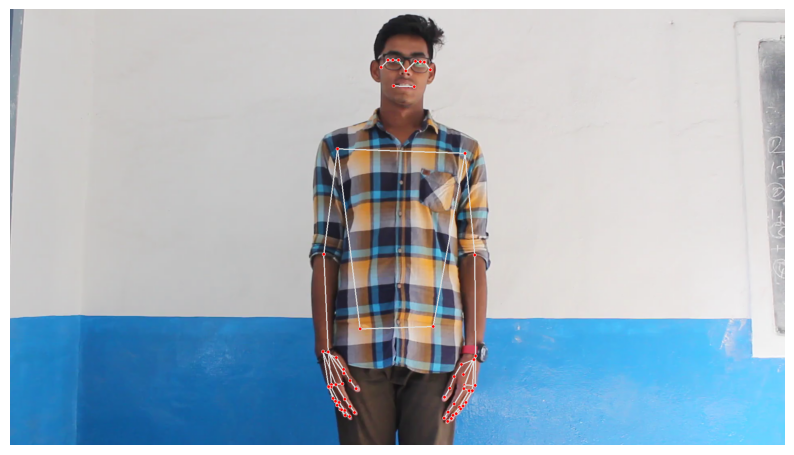

In [40]:
def display_cv2_image(img, figsize = (10,10)):
    img_ = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    fig,ax = plt.subplots(figsize=figsize)
    ax.imshow(img_)
    ax.axis('off')
    
ret, frame = cap.read()

img,res = mediapipe_detection(frame, mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5))

cap.release()

draw_landmarks(img, res)

display_cv2_image(img)



In [41]:
input_path_I50.sample(10)

316         Dataset\Electronics/53. Fan/MVI_9098.MP4
453          Dataset\Adjectives/1. loud/MVI_5257.mp4
599          Dataset\Adjectives/97. dry/MVI_9522.mp4
206        Dataset\Adjectives/79. short/MVI_5112.mp4
403             Dataset\Home/28. Window/MVI_4881.mp4
340         Dataset\Clothes/42. T-Shirt/MVI_5169.mp4
145    Dataset\Places/28. Store or Shop/MVI_3385.mp4
67       Dataset\Days_and_Time/86. Time/MVI_5524.mp4
586         Dataset\Adjectives/2. quiet/MVI_5262.mp4
315    Dataset\Places/28. Store or Shop/MVI_3387.mp4
dtype: object

In [53]:
holistic = mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5)
DATA_PATH = "MP_data/"
    
# Loop through sequences aka videos
for input_path in tqdm(input_path_I50):
    cap = cv2.VideoCapture(input_path)
    all_keypoints = []
    keypoints = np.array(None)
        
    while cap.isOpened():           
        # Read feed
        ret, frame = cap.read()
        if not ret:
            break
        
        # Make detections
        image, results = mediapipe_detection(frame, holistic)

        # Draw landmarks
        draw_styled_landmarks(image, results)
            
        #Collecting 3D landmarks for a single frame
        keypoints = extract_keypoints(results)
        all_keypoints.append(keypoints)        
    
    all_keypoints = np.vstack(all_keypoints)
    
    # Saving Landmarks
    path = input_path.split("/")
    
    # Getting Current action of the video
    action = path[-2]
    action = action.split(" ")[1:]
    action = " ".join(action)
    
    #Get the sequence number
    sequence = path[-1]
    sequence = sequence.split(".")[0]
    
    npy_path = os.path.join(DATA_PATH, action, sequence)
    print(npy_path)
    
    np.save(npy_path, all_keypoints)

    cap.release()

  0%|          | 0/689 [00:00<?, ?it/s]

MP_data/loud\MVI_9448
MP_data/House\MVI_3515
MP_data/big large\MVI_5204
MP_data/Priest\MVI_5345
MP_data/Court\MVI_3612
MP_data/train ticket\MVI_8596
MP_data/Court\MVI_3531
MP_data/it\MVI_0014
MP_data/House\MVI_3436
MP_data/Shoes\MVI_3711
MP_data/Dog\MVI_3060
MP_data/Dog\MVI_3060
MP_data/Dog\MVI_3030
MP_data/Thank you\MVI_0111
MP_data/Election\MVI_4307
MP_data/Cow\MVI_3047
MP_data/Window\MVI_8769
MP_data/quiet\MVI_5338
MP_data/dry\MVI_5328
MP_data/long\MVI_5186
MP_data/Hello\MVI_0090
MP_data/dry\MVI_9523
MP_data/Hello\MVI_9983
MP_data/Cow\MVI_2992
MP_data/Bird\MVI_4155
MP_data/Court\MVI_3610
MP_data/big large\MVI_9317
MP_data/Bank\MVI_3502
MP_data/Hat\MVI_3985
MP_data/Black\MVI_5206
MP_data/quiet\MVI_9452
MP_data/short\MVI_9380
MP_data/Bank\MVI_3337
MP_data/Cow\MVI_2990
MP_data/White\MVI_3891
MP_data/short\MVI_5270
MP_data/Bank\MVI_3583
MP_data/Fan\MVI_9099
MP_data/House\MVI_3268
MP_data/new\MVI_9502
MP_data/Store or Shop\MVI_3308
MP_data/Monday\MVI_5449
MP_data/Black\MVI_4040
MP_data/H